# EDA for NATIONAL Top Spotify Songs in 73 Countries (Daily Updated) dataset.
- [Clean dataset from data/processed in .parquet](../data/processed/spotify_daily_top_songs_clean_version608.parquet)
- [Clean dataset from data/processed in .csv](../data/processed/spotify_daily_top_songs_clean_version608.csv)
- Original dataset from: https://www.kaggle.com/datasets/asaniczka/top-spotify-songs-in-73-countries-daily-updated/versions/493


In [43]:
import pandas as pd
import duckdb
import matplotlib.pyplot as plt
import seaborn as sns

# Mina konstanter rörs ej (Skrivs med ALL CAPS i Python)
PARQUET_FILE = "../data/processed/spotify_daily_top_songs_clean_version608.parquet"

df = pd.read_parquet(PARQUET_FILE)

In [33]:
# Utforska datatyperna
print("\n=== DTYPES (Datatypes) CLEANED FILE ===")
print(df.dtypes)



=== DTYPES (Datatypes) CLEANED FILE ===
spotify_id                       str
name                             str
artists                          str
daily_rank                     int64
daily_movement                 int64
weekly_movement                int64
country                          str
snapshot_date         datetime64[us]
popularity                     int64
is_explicit                     bool
duration_ms                    int64
album_name                       str
album_release_date               str
danceability                 float64
energy                       float64
key                            int64
loudness                     float64
mode                           int64
speechiness                  float64
acousticness                 float64
instrumentalness             float64
liveness                     float64
valence                      float64
tempo                        float64
time_signature                 int64
month                          int

In [34]:
# Söka efter NULL values
print("\n=== NULL-VALUES (How much trash do I have?) ===")
print(df.isnull().sum())


=== NULL-VALUES (How much trash do I have?) ===
spotify_id              0
name                    0
artists                 0
daily_rank              0
daily_movement          0
weekly_movement         0
country                 0
snapshot_date           0
popularity              0
is_explicit             0
duration_ms             0
album_name            792
album_release_date    630
danceability            0
energy                  0
key                     0
loudness                0
mode                    0
speechiness             0
acousticness            0
instrumentalness        0
liveness                0
valence                 0
tempo                   0
time_signature          0
month                   0
year_month              0
dtype: int64


In [35]:
# Första 3 rows
df.head(3)

,spotify_id,name,artists,daily_rank,daily_movement,weekly_movement,country,snapshot_date,popularity,is_explicit,...,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,month,year_month
0,2RkZ5LkEzeHGRsmDqKwmaJ,Ordinary,Alex Warren,1,1,0,Global,2025-06-11,95,False,...,1,0.0600,0.704000,0.000007,0.0550,0.391,168.115,3,6,2025-06
1,42UBPzRMh5yyz0EDPr6fr1,Manchild,Sabrina Carpenter,2,-1,48,Global,2025-06-11,89,True,...,1,0.0572,0.122000,0.000000,0.3170,0.811,123.010,4,6,2025-06
2,0FTmksd2dxiE5e3rWyJXs6,back to friends,sombr,3,0,1,Global,2025-06-11,98,False,...,1,0.0301,0.000094,0.000088,0.0929,0.235,92.855,4,6,2025-06


# The cultural meter. Which countries listen to the most explicit music?

**Steps:**
```markdown
1) Filter out 'Global' to look only at the national level.
2) Group by country and calculate:
    - Average of is_explicit (which will be my percentage).
    - Number of unique songs (to filter out statistical "noise").
3) Convert the average to real percentages (e.g. 0.45 -> 45.0%).
4) Filter out countries with few songs, sort from highest to lowest, and take the top 10.
```

## Insights:
- See [[Top spotify songs insights](../docs/eda_insights/top_spotify_songs_countries.md)]

In [36]:
# ====================
# Insikt 1: Mest explicita länderna
# ====================

# 1):
df_countries = df[df['country'] != 'global'] 

# 2):
explicit_stats = df_countries.groupby('country').agg(
    explicit_percentage=('is_explicit', 'mean'),
    total_unique_songs=('spotify_id', 'nunique')
).reset_index()

# 3):
explicit_stats['explicit_percentage'] = (explicit_stats['explicit_percentage'] * 100).round(1)

# 4):
top_explicit_countries = explicit_stats[explicit_stats['total_unique_songs'] > 100].sort_values(by='explicit_percentage', ascending=False).head(10)

# få ut informationen
print("Worlds top 10 most 'Explicit' Nations according to Spotifys data:")
print(top_explicit_countries.to_string(index=False))


Worlds top 10 most 'Explicit' Nations according to Spotifys data:
country  explicit_percentage  total_unique_songs
     GR                 68.5                 904
     CL                 64.4                 597
     DO                 60.8                 873
     MX                 57.3                 495
     SK                 56.4                 944
     FR                 54.1                 903
     BY                 52.9                 772
     SV                 51.6                 572
     GT                 51.5                 443
     CZ                 50.7                 845


# The extremes (Happiness(Valence) and Tempo(BPM))
- Which Country is the "happiest" country looking at its Valance scores AND BPM scores.


## Insights
- 

In [82]:
# ====================
# Insikt 2 och 3: Glädje extremes och Tempo "kungar"
# ====================
query_mood_tempo = f"""
SELECT 
    country,
    AVG(valence) * 100 as happiness_score,
    AVG(tempo) as avg_bpm,
    COUNT(DISTINCT spotify_id) as unique_songs_played
FROM '{PARQUET_FILE}'
WHERE country != 'Global'
GROUP BY country
HAVING unique_songs_played > 100
"""
# Hämta datan
df_mood_tempo = duckdb.query(query_mood_tempo).df()

# Sortera och ta fram alla extremes
top_happy = df_mood_tempo.sort_values(by='happiness_score', ascending=False).head(10)
top_sad = df_mood_tempo.sort_values(by='happiness_score', ascending=True).head(10)
top_fast = df_mood_tempo.sort_values(by='avg_bpm', ascending=False).head(10)
# Top 10 "gladaste" musik nationerna
print("---- TOP 10 HAPPIEST NATIONS ----")
print(top_happy[['country', 'happiness_score']].to_string(index=False))
# Top 10 "sad" musik nationerna
print("\n---- TOP 10 SADDEST NATIONS ----")
print(top_sad[['country', 'happiness_score']].to_string(index=False))

---- TOP 10 HAPPIEST NATIONS ----
country  happiness_score
     MX        67.377447
     UY        65.911509
     BR        65.296959
     GT        63.675198
     JP        63.652883
     AR        63.439812
     BG        63.291541
     BO        62.084481
     NG        62.063847
     EG        61.734741

---- TOP 10 SADDEST NATIONS ----
country  happiness_score
     ID        37.439920
     MY        44.311141
     IL        46.780425
     SK        47.727962
     CZ        48.582610
     VN        48.695497
     HK        49.095845
     US        49.391595
     TW        49.415677
     AE        49.695890


In [84]:
# Top 10 Högsta BPM nationerna
print("\n---- TOP 10 HIGHEST BPM NATIONS ----")
print(top_fast[['country', 'avg_bpm']].to_string(index=False))


---- TOP 10 HIGHEST BPM NATIONS ----
country    avg_bpm
     BG 135.407573
     HK 132.272957
     RO 130.208089
     JP 129.068860
     CZ 128.620991
     EE 128.229282
     SK 127.526495
     AT 127.412335
     BR 127.252968
     DE 126.945929


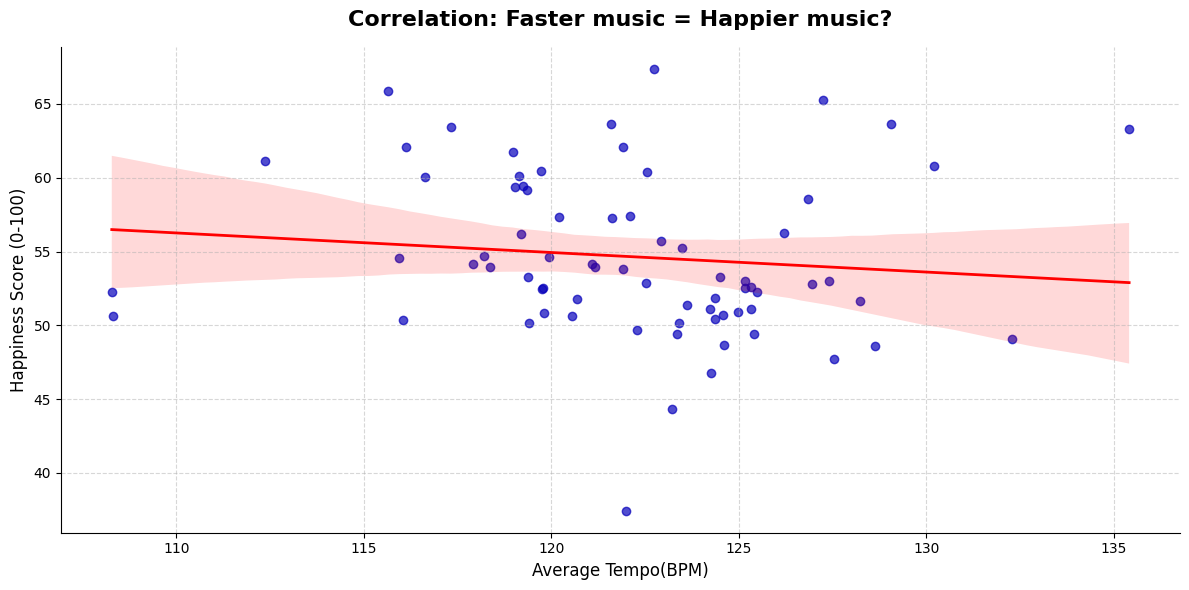

In [46]:
# ====================
# Insikt 4: Är snabb musik verkligen glad musik?
# Visuella insikter
# ====================

fig, ax = plt.subplots(figsize=(12, 6))

# sns.regplot ritar alla länder som prickar och drar en trendlinje
sns.regplot(
    data=df_mood_tempo,
    x="avg_bpm",
    y="happiness_score",
    scatter_kws={"alpha": 0.7, "color": "#0701BB"},
    line_kws={"color": "red", "linewidth": 2},
    ax=ax,
)

ax.set_title('Correlation: Faster music = Happier music?', fontsize=16, fontweight='bold', pad=15)
ax.set_xlabel('Average Tempo(BPM)', fontsize=12)
ax.set_ylabel('Happiness Score (0-100)', fontsize=12)

ax.grid(True, linestyle='--', alpha=0.5)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

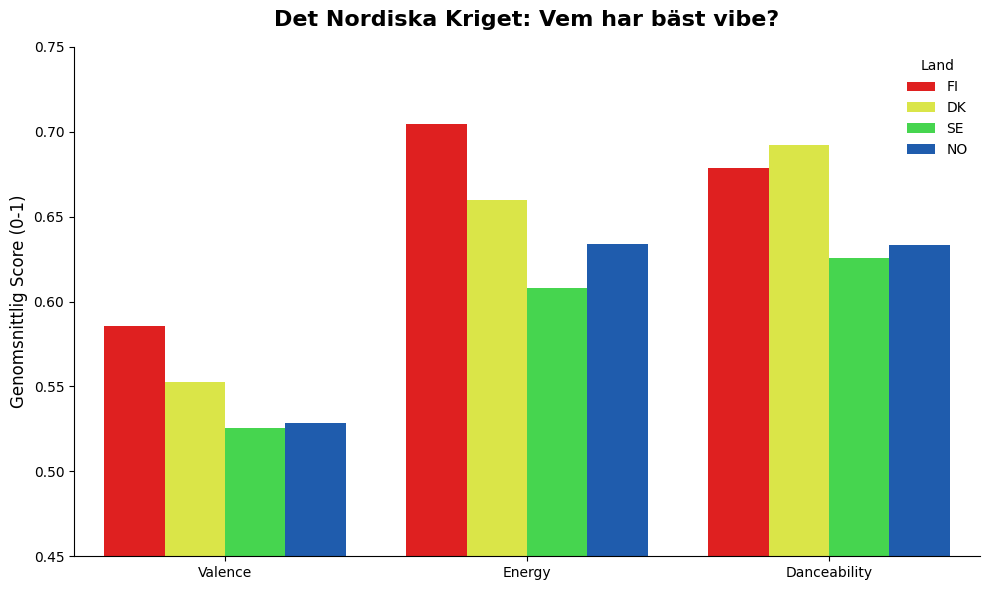

In [86]:
# ==========================================
# INSIKT 5: Det Nordiska Musikkriget
# ==========================================
query_nordic = f"""
SELECT 
    country,
    AVG(valence) as Valence,
    AVG(energy) as Energy,
    AVG(danceability) as Danceability
FROM '{PARQUET_FILE}'
WHERE country IN ('SE', 'NO', 'DK', 'FI')
GROUP BY country
"""
df_nordic = duckdb.query(query_nordic).df()

# "Smält" datan för att kunna göra grupperade staplar i Seaborn
df_nordic_melted = df_nordic.melt(id_vars='country', var_name='Audio_Feature', value_name='Score')

fig, ax = plt.subplots(figsize=(10, 6))

# Skapa ett grupperat stapeldiagram
sns.barplot(
    data=df_nordic_melted, 
    x='Audio_Feature', 
    y='Score', 
    hue='country', 
    palette=["#FF0000FF", "#F1FF2E", "#2EED3A", "#0759C5"], # "Temafärger" för flaggorna (ungefär)
    ax=ax
)

ax.set_title('Det Nordiska Kriget: Vem har bäst vibe?', fontsize=16, fontweight='bold', pad=15)
ax.set_xlabel('', fontsize=12)
ax.set_ylabel('Genomsnittlig Score (0-1)', fontsize=12)

# zoomar in mer på y-axeln mellan 0.45 och 0.75 för att skillnaderna (som är små) ska synas!
ax.set_ylim(0.45, 0.75) 

ax.legend(title='Land', frameon=False, loc='upper right')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()